In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import zarr
from diffusion_policy.common.replay_buffer import ReplayBuffer
from omegaconf import OmegaConf
from diffusion_policy.codecs.imagecodecs_numcodecs import register_codecs
from umi.common.pose_util import (
    pose_to_mat, mat_to_pose, 
    mat_to_pose10d, pose10d_to_mat)
from diffusion_policy.common.pose_repr_util import convert_pose_mat_rep



In [2]:
OmegaConf.register_new_resolver("eval", eval, replace=True)
register_codecs()

In [4]:
zarr_path = '/home/soochul/GoPro_20250509/dataset.zarr.zip'
# zarr_path = '/home/soochul/dataset0320.zarr.zip'
zip_store = zarr.ZipStore(zarr_path, mode='a')
root = zarr.group(zip_store)
replay_buffer = ReplayBuffer.create_from_group(root)
num_episodes = len(replay_buffer.episode_ends)
print(f"Loaded replay buffer with {num_episodes} episodes.")
episode_idx = np.random.choice(num_episodes)
print(f"Replaying episode {episode_idx}...")
ep = replay_buffer.get_episode(episode_idx)
# print(ep.keys()) 
# dict_keys(['camera0_rgb', 'robot0_demo_end_pose', 'robot0_demo_start_pose', 
# 'robot0_eef_pos', 'robot0_eef_rot_axis_angle', 
# 'robot0_force', 'robot0_gripper_width', 'robot0_torque'])
for robot_idx in range(1):
    pos_replay = ep[f'robot{robot_idx}_eef_pos'][:]
    rot_replay = ep[f'robot{robot_idx}_eef_rot_axis_angle'][:]
    grip_replay = ep[f'robot{robot_idx}_gripper_width'][:]
actions = np.concatenate([pos_replay, rot_replay, grip_replay], axis=-1)

Loaded replay buffer with 261 episodes.
Replaying episode 205...


In [5]:
# action processing
pose_mat = pose_to_mat(np.concatenate([
    pos_replay, rot_replay
], axis = -1))
print(pose_mat.shape)
print(actions[0, 0:6])
action_mat = pose_to_mat(actions[..., 0: 6])
action_pose_mat = convert_pose_mat_rep(
                action_mat, 
                base_pose_mat=pose_mat[-1],
                pose_rep='rel',
                backward=False)
action_pose10d = mat_to_pose10d(action_pose_mat)
print(action_pose10d[0])
action_pose_mat_ = pose10d_to_mat(action_pose10d)
print(action_pose_mat[0])
action_mat = convert_pose_mat_rep(
    action_pose_mat_,
    base_pose_mat=pose_mat[-1],
    pose_rep='rel',
    backward=True
)
print(action_mat[0])
action_pose = mat_to_pose(action_mat)
print(action_pose[0])

(670, 4, 4)
[-0.01622557 -0.38876045  0.5015174  -2.48514    -0.04586506  0.16056675]
[-0.01616305 -0.030148    0.03513482  0.9959234  -0.07204492  0.0542778
  0.06626678  0.99261296  0.10162686]
[[ 0.9959234  -0.07204492  0.0542778  -0.01616305]
 [ 0.06626678  0.99261296  0.10162686 -0.030148  ]
 [-0.06119854 -0.09761576  0.99334073  0.03513482]
 [ 0.          0.          0.          1.        ]]
[[ 0.9919292  -0.0060675  -0.12664811 -0.01622557]
 [ 0.0720467  -0.7949612   0.60236704 -0.38876045]
 [-0.1043352  -0.60662997 -0.78810805  0.5015174 ]
 [ 0.          0.          0.          1.        ]]
[-0.01622557 -0.38876045  0.5015174  -2.48514    -0.04586507  0.16056676]


In [ ]:
action_lists = pickle.load(open('/home/jaco/actions.pkl', 'rb'))

In [ ]:
all_norm_actions = action_lists[0]
all_unnorm_actions = action_lists[1]
all_real_umi_actions = action_lists[2]
all_target_actions = action_lists[-1]

In [ ]:
max_ep_length = len(all_unnorm_actions)
norm_action = np.zeros(shape=(max_ep_length, 4))
unnorm_action = np.zeros(shape=(max_ep_length, 4))
real_umi_action = np.zeros(shape=(max_ep_length, 4))
target_action = np.zeros(shape=(max_ep_length, 4))

for idx, action in enumerate(all_norm_actions):
    norm_action[idx, :3] = action[:3]
    norm_action[idx, -1] = action[-1]

for idx, action in enumerate(all_unnorm_actions):
    unnorm_action[idx, :3] = action[:3]
    unnorm_action[idx, -1] = action[-1]

for idx, action in enumerate(all_real_umi_actions):
    real_umi_action[idx, :3] = action[:3]
    real_umi_action[idx, -1] = action[-1]

for idx, action in enumerate(all_target_actions):
    target_action[idx, :3] = action[0][:3]
    target_action[idx, -1] = action[0][-1]

In [ ]:
pos_replay = pos_replay[:max_ep_length, ...]
grip_replay = grip_replay[:max_ep_length, ...]

In [ ]:
norm_action.shape

In [ ]:
def plot_pos(pose_comms):
    # Extract x, y, z coordinates
    x = pose_comms[:, 0]
    y = pose_comms[:, 1]
    z = pose_comms[:, 2]

    # Generate colors based on order (index)
    colors = np.linspace(0, 1, len(x))  # Normalize order for color mapping

    # Create the 3D scatter plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot with gradient colors
    sc = ax.scatter(x, y, z, c=colors, cmap='cool', s=50)

    # Add labels and colorbar
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    cb = plt.colorbar(sc)
    cb.set_label('Point Order')

    plt.show()

In [ ]:
def plot_width(pose_comms):
    # Extract gripper width
    x = range(pose_comms.shape[0])
    y = pose_comms[:, -1]

    # Add labels and colorbar
    plt.plot(x, y)
    plt.show()

In [ ]:
plot_pos(pos_replay)

In [ ]:
plot_pos(norm_action)

In [ ]:
plot_pos(unnorm_action)

In [ ]:
plot_pos(real_umi_action)

In [ ]:
plot_pos(target_action)

In [ ]:
plot_width(grip_replay)

In [ ]:
plot_width(norm_action)
# -0.45 ~ -0.51

In [ ]:
plot_width(unnorm_action)
# 0.024 ~ 0.010

In [ ]:
plot_width(real_umi_action)
# -0.45 ~ -0.51 (before)
# 0.024 ~ 0.010 (after i fixed my mistake)

In [ ]:
def plot_pos_multi(ax, pose_comms, title=""):
    # Extract x, y, z coordinates
    x = pose_comms[:, 0]
    y = pose_comms[:, 1]
    z = pose_comms[:, 2]

    # Generate colors based on order (index)
    colors = np.linspace(0, 1, len(x))  # Normalize order for color mapping

    # Scatter plot with gradient colors
    sc = ax.scatter(x, y, z, c=colors, cmap='cool', s=5)

    # Add labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)

[182  56 100 180  73  17  64  40  35 124 206  15 141 114  42 155 131 148
 196  34 120 134  94 207 119  96 257 104 238 260 142 176 194 204 210 178
 125  10  89 118 186  74 170  49 173 112 158 174 202   6 117 193  82  48
 192 132 236  67  93  24 208 144  97  99]


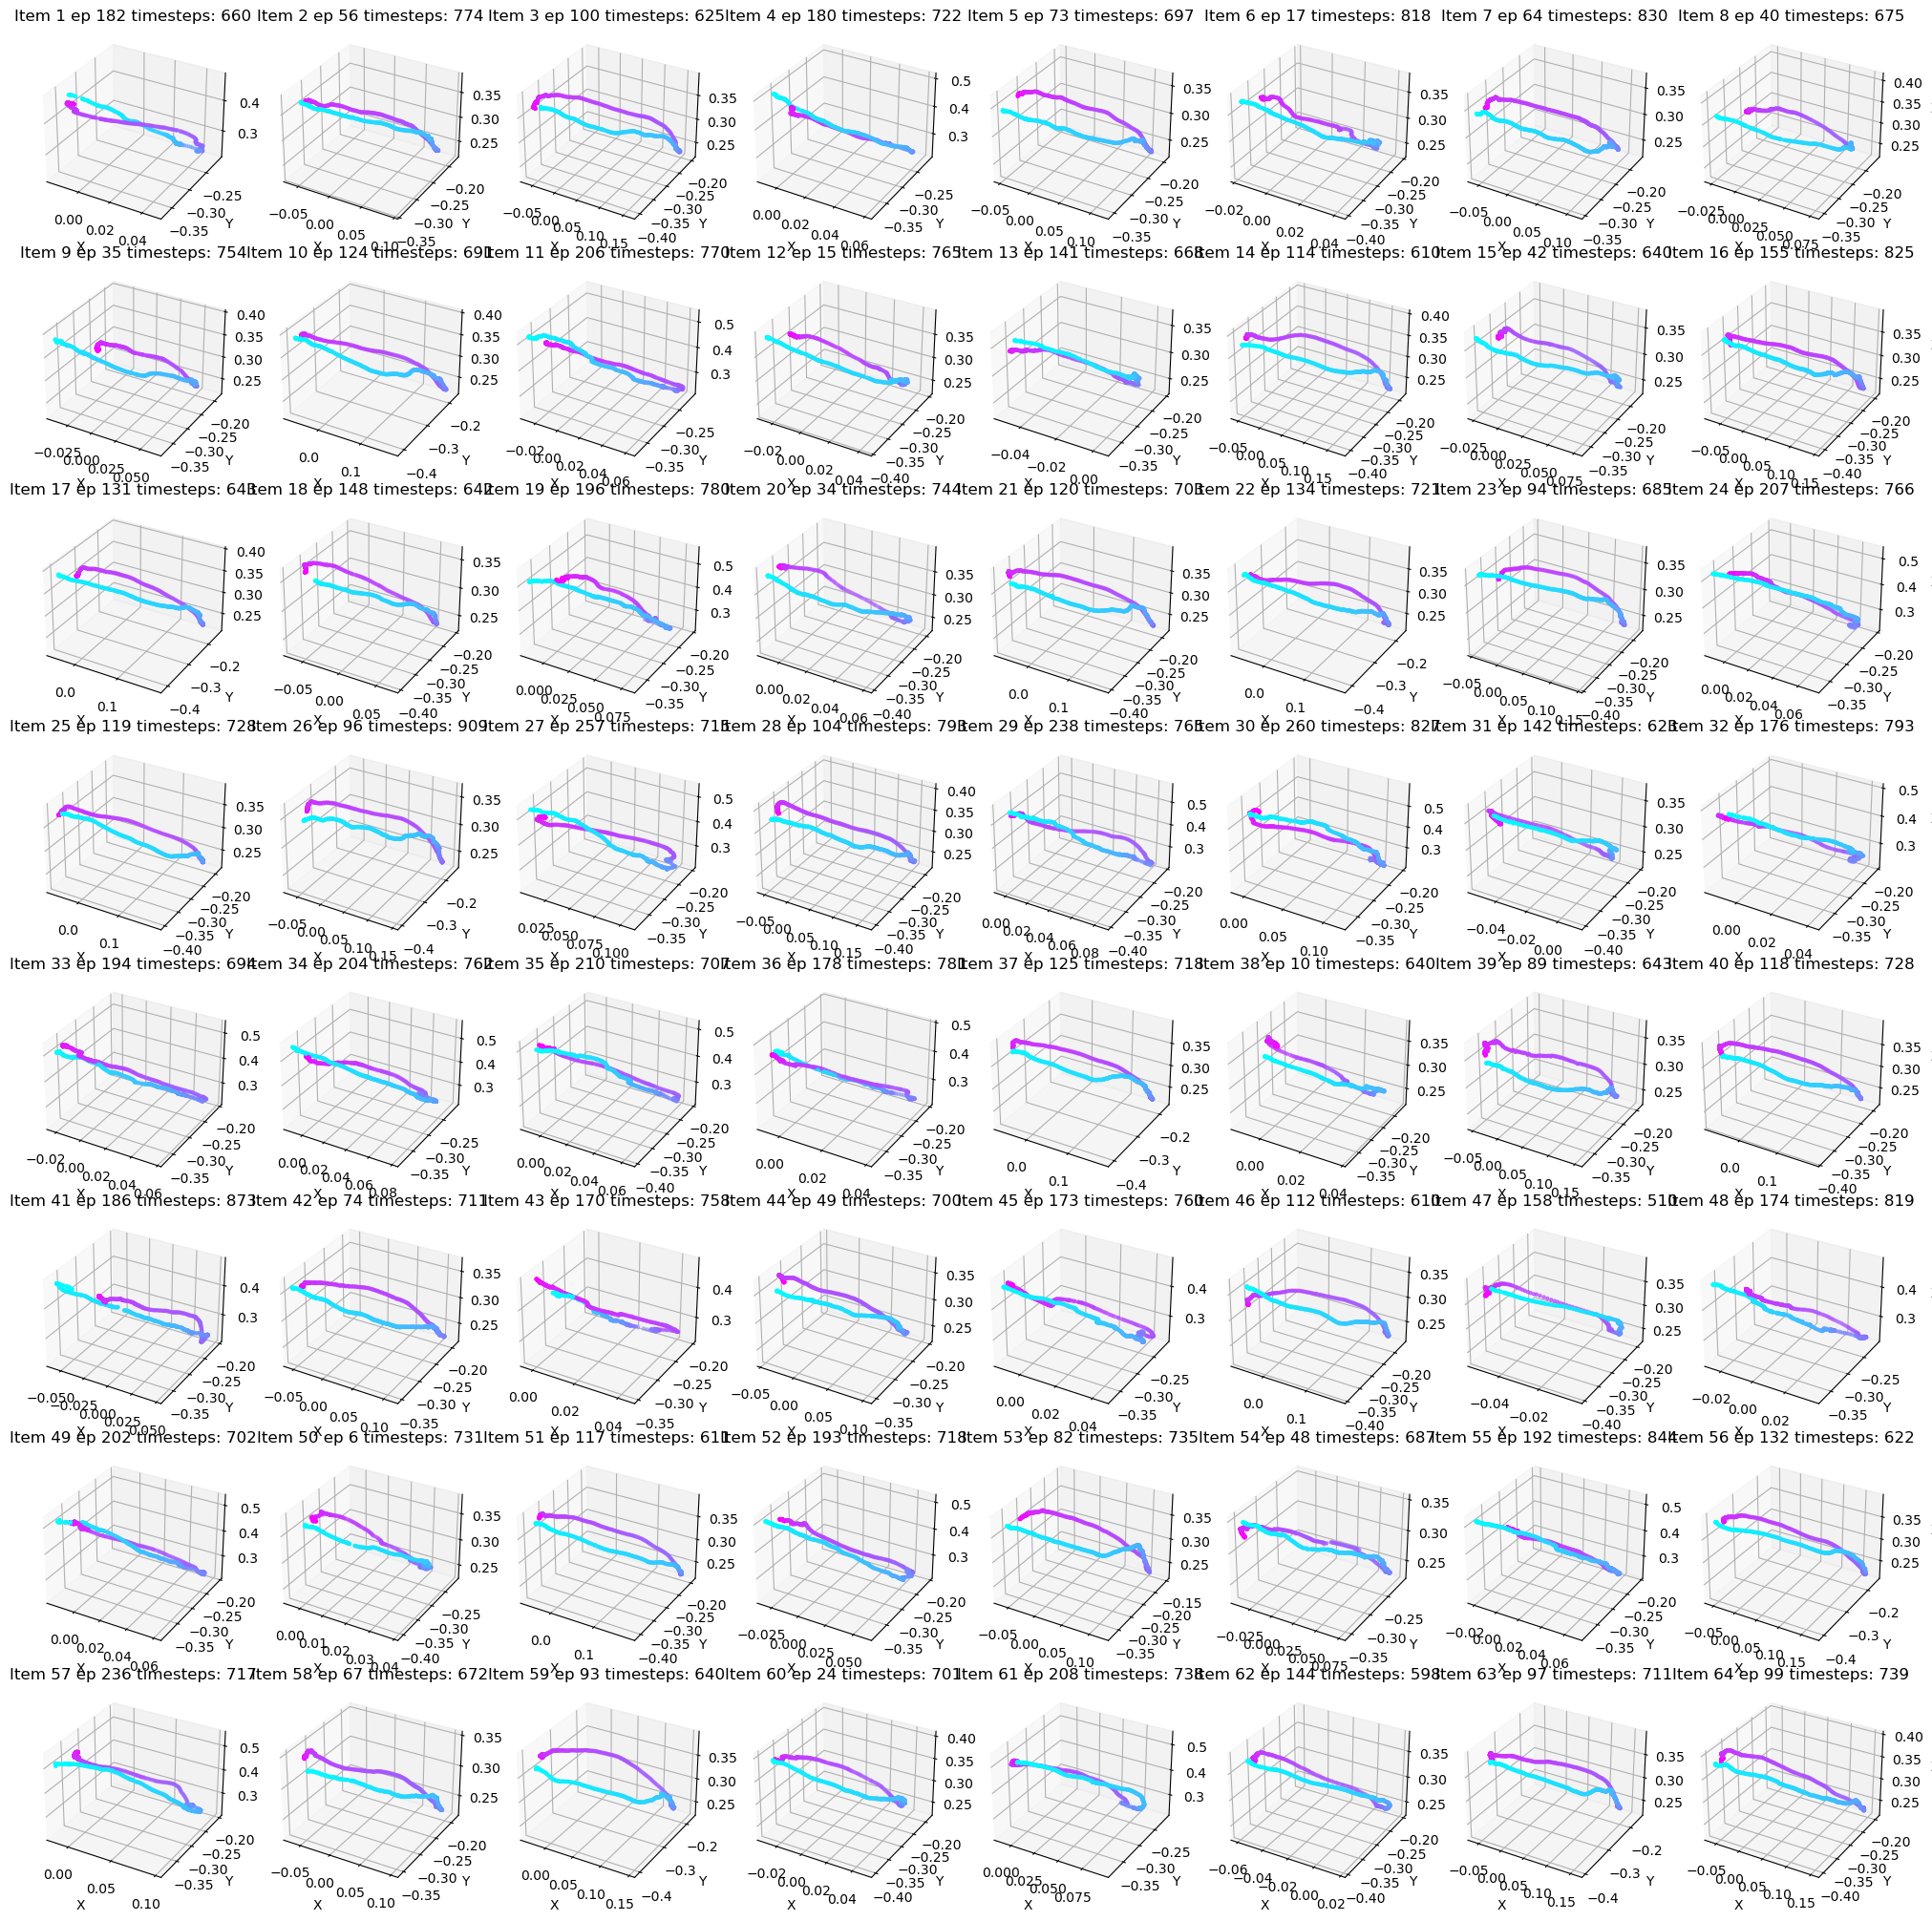

In [9]:
num_episodes = len(replay_buffer.episode_ends)
num_episodes_random = 64 #16
random_episodes = np.random.choice(num_episodes, num_episodes_random, replace=False)
print(random_episodes)
fig = plt.figure(figsize=(20, 20))
rows = int(np.ceil(np.sqrt(num_episodes_random)))
cols = int(np.ceil(num_episodes_random / rows))
for idx, ep_idx in enumerate(random_episodes):
    episode = replay_buffer.get_episode(ep_idx)
    each_pos_replay = episode['robot0_eef_pos'][:]

    ax = fig.add_subplot(rows, cols, idx + 1, projection='3d')
    plot_pos_multi(ax, each_pos_replay, title=f"Item {idx+1} ep {ep_idx} timesteps: {len(episode['robot0_eef_pos'])}")

plt.tight_layout()
plt.show()

In [ ]:
mean_start_pos_list = list()
mean_start_rot_list = list()
num_episodes = len(replay_buffer.episode_ends)

for ep_idx in range(num_episodes):
    print(ep_idx)
    episode = replay_buffer.get_episode(ep_idx)
    each_pos_replay = episode['robot0_eef_pos'][:]
    each_rot_replay = episode['robot0_eef_rot_axis_angle'][:]

    each_ep_length = len(each_pos_replay)
    start_duration = int(each_ep_length * 0.01)
    each_start_pos = episode['robot0_eef_pos'][:start_duration]
    mean_start_pos_list.append(each_start_pos)

    each_start_rot = episode['robot0_eef_rot_axis_angle'][:start_duration]
    mean_start_rot_list.append(each_start_rot)


In [ ]:
mean_start_pos_array = np.concatenate(mean_start_pos_list, axis=0)
mean_start_rot_array = np.concatenate(mean_start_rot_list, axis=0)

In [ ]:
mean_x = np.mean(mean_start_pos_array[:, 0])
mean_y = np.mean(mean_start_pos_array[:, 1])
mean_z = np.mean(mean_start_pos_array[:, 2])

mean_rx = np.mean(mean_start_rot_array[:, 0])
mean_ry = np.mean(mean_start_rot_array[:, 1])
mean_rz = np.mean(mean_start_rot_array[:, 2])


In [ ]:
mean_x # -0.08782661


In [ ]:
mean_y # -0.13807559
# -0.13376735


In [ ]:
mean_z # 0.093378246
# 0.09266995


In [ ]:
mean_rx
# -2.1256728

In [ ]:
mean_ry
# 0.0827507


In [ ]:
mean_rz
# 0.052626412

In [ ]:
import time
import rtde_control
from rtde_control import RTDEControlInterface
from rtde_io import  RTDEIOInterface
from rtde_receive import RTDEReceiveInterface

In [ ]:
# mean_x = 0.058042273
# mean_y = -0.13376735
# mean_z = 0.09266995
# mean_rx = -2.1256728
# mean_ry = 0.0827507
# mean_rz = 0.052626412

In [ ]:
ur_ip = "192.168.3.168" 

In [ ]:
rtde_c = RTDEControlInterface(ur_ip)

In [ ]:
rtde_r = RTDEReceiveInterface(ur_ip)

In [ ]:
rtde_r.getActualTCPPose()

In [ ]:
target_pose = [mean_x, mean_y, mean_z, mean_rx, mean_ry, mean_rz]
target_pose

In [ ]:
duration = 20.0  
lookahead_time = 0.1  
gain = 300.0
velocity = 0.5  
acceleration = 0.5

# Move using servoL
rtde_c.servoL(target_pose, velocity, acceleration, duration, lookahead_time, gain)

# Keep sending commands to maintain servoL (It requires continuous updates)
start_time = time.time()
while time.time() - start_time < duration:
    rtde_c.servoL(target_pose, velocity, acceleration, duration, lookahead_time, gain)
    time.sleep(0.008)  # Update every 8ms (recommended)


In [ ]:
rtde_c.disconnect()